In [1]:
# Storyboard — three densities (regular / extra / super).
# Grid of rectangle outlines, tiled exactly within the usable rectangle.
# Adjacent cells share borders (drawn twice but identical — no artifact).
#
# CONSTRAINT: cell_w × cols == WIDTH − 2·MARGIN = 8260, and cell_h × rows ==
# HEIGHT − HEADER_HEIGHT − 2·MARGIN = 10510. Configurations are limited to
# (cols, rows) where cols divides 8260 (= 2²·5·7·59: {2,4,5,7,10,...}) and
# rows divides 10510 (= 2·5·1051: {2,5,10}). All three densities preserve
# exact 120 px margins on all four sides.
#
# Output: ../output/storyboard/{storyboard,extra-storyboard,super-storyboard}.png
from PIL import Image, ImageDraw
from IPython.display import display
from common import (
    blank_page, draw_header, FG_COLOR, ELEM_SIZE,
    WIDTH, HEIGHT, MARGIN, HEADER_HEIGHT,
    output_path, variant_name,
)

MODE = "storyboard"

USABLE_W = WIDTH - 2 * MARGIN                    # 8260
USABLE_H = HEIGHT - HEADER_HEIGHT - 2 * MARGIN   # 10510

# (cols, rows) per density. cols must divide USABLE_W; rows must divide USABLE_H.
GRID = {
    "regular": (2,  2),    # cell 4130 × 5255   —  4 large frames
    "extra":   (4,  5),    # cell 2065 × 2102   — 20 medium frames
    "super":   (5, 10),    # cell 1652 × 1051   — 50 small frames
}

In [2]:
def render_storyboard(cols, rows):
    assert USABLE_W % cols == 0 and USABLE_H % rows == 0
    cw = USABLE_W // cols
    ch = USABLE_H // rows
    img = blank_page()
    draw = ImageDraw.Draw(img)
    for i in range(cols):
        for j in range(rows):
            left   = MARGIN + i * cw
            top    = HEADER_HEIGHT + MARGIN + j * ch
            right  = left + cw - 1
            bottom = top + ch - 1
            draw.rectangle([left, top, right, bottom],
                           outline=FG_COLOR, width=ELEM_SIZE)
    draw_header(img)
    return img, cw, ch

regular  2×2 =  4 frames  cell 4130×5255  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/storyboard/storyboard.png


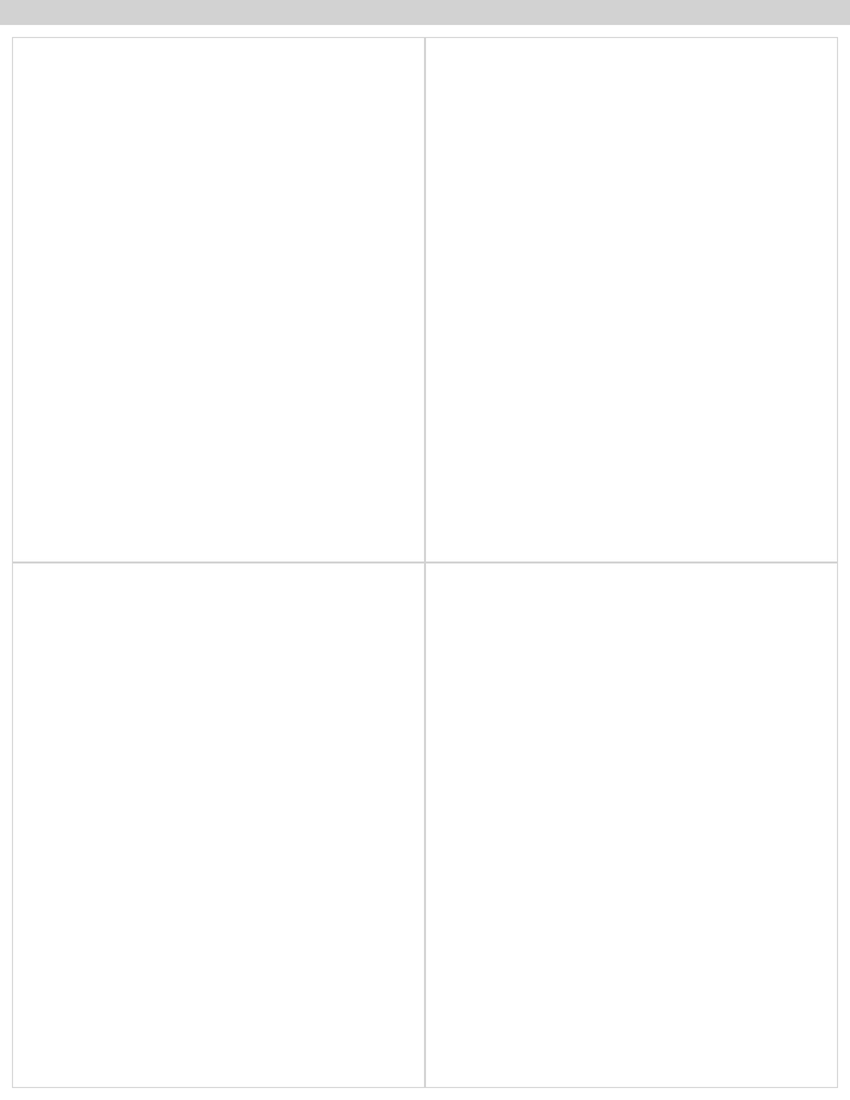

extra    4×5 = 20 frames  cell 2065×2102  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/storyboard/extra-storyboard.png


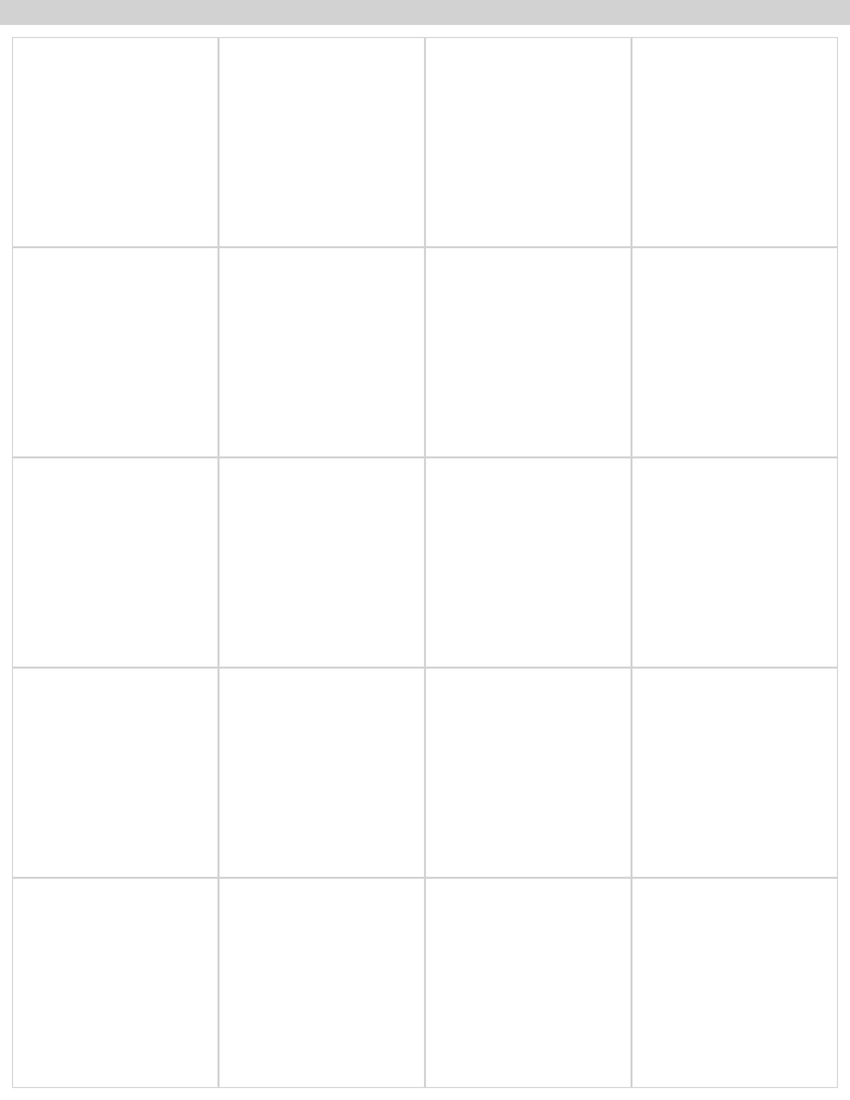

super    5×10 = 50 frames  cell 1652×1051  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/storyboard/super-storyboard.png


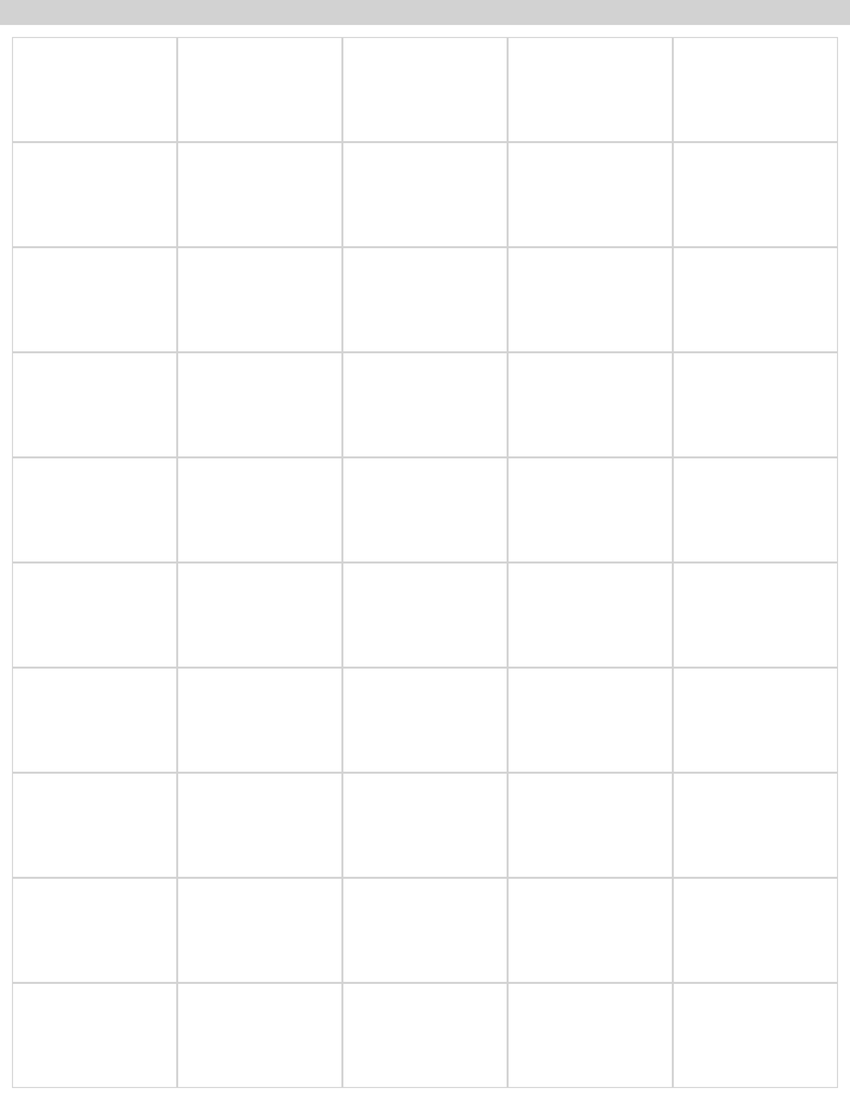

In [3]:
for density, (cols, rows) in GRID.items():
    img, cw, ch = render_storyboard(cols, rows)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} {cols}×{rows} = {cols*rows:2d} frames  "
        f"cell {cw}×{ch}  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))